**Transformer 为何需要位置编码**

标准 self-attention 的计算是：

```
Attention(Q, K, V) = softmax( Q Kᵀ / √d ) V
```

其中 Q、K、V 是对输入序列做线性变换得到的。注意：这个操作对序列中 token 的**排列顺序是完全不敏感的**。"猫咬了狗" 和 "狗咬了猫" 会产生完全相同的注意力权重矩阵（仅仅是行列被重新排列）。因此必须在某个阶段将位置信息注入模型。

早期的绝对位置编码（Sinusoidal PE，见 Transformer 原始论文）直接将一个与位置相关的向量加到 token embedding 上。其缺陷在于：它对绝对位置敏感，但模型更需要的往往是**相对位置**（"这个词距离那个词多远"），而非"这个词在序列的第几位"。RoPE 的设计正是为了让注意力分数自然地只依赖相对位置。

**RoPE 的核心思想**

RoPE（Su et al. 2022）的出发点是一个非常优雅的要求：设计一种函数 `f(x, m)`，将位置 `m` 处的向量 `x` 变换为 `x_m`，使得对于任意两个位置 `m`（query）和 `n`（key），它们的内积**只依赖于相对位置差 `n - m`**：

```
⟨f(q, m),  f(k, n)⟩  =  g(q, k, n − m)
```

这个性质一旦满足，attention score `q_m · k_n` 就天然编码了相对位置，无需额外的相对位置计算。

**在 2D 情形下，这个条件有精确的解：旋转矩阵。** 对于 2D 向量，令：

```
f(x, m) = R(m · θ) · x，   其中  R(α) = [[cos α, −sin α],
                                          [sin α,  cos α]]
```

则：
```
f(q, m)ᵀ f(k, n) = qᵀ R(m·θ)ᵀ R(n·θ) k
                  = qᵀ R((n−m)·θ) k
```

因为旋转矩阵满足 `R(α)ᵀ R(β) = R(β − α)`（旋转是正交变换，逆 = 转置）。结果只依赖 `n − m`，完美满足要求。

**从 2D 到 d 维：独立的频率平面**

实际注意力头的维度 `d` 通常为 64 或 128。RoPE 将这 `d` 个维度**两两配对**，分成 `d/2` 个独立的 2D 旋转子空间。第 `i` 个子空间（维度 `2i` 和 `2i+1`）使用自己的旋转频率：

```
θ_i = base^{−2i/d}，    base = 10000（默认），    i = 0, 1, …, d/2 − 1
```

对应的**波长**（旋转一周需要多少个位置）为：

```
λ_i = 2π / θ_i = 2π × base^{2i/d}
```

关键观察：`i = 0` 时 `θ_0 = 1`，波长 `λ_0 = 2π ≈ 6.3`（极高频，每 6 个位置旋转一周）；`i = d/2 - 1` 时 `θ` 极小，`λ` 可达数万个位置（极低频，旋转极慢）。

完整的 RoPE 变换可以写成对角块矩阵的形式：

```
R(m) = block-diag( R(m·θ_0),  R(m·θ_1),  …,  R(m·θ_{d/2−1}) )
```

整体 dot product 为各子空间的加和：
```
q_m · k_n = Σ_{i=0}^{d/2−1}  q_i^T  R((n−m)·θ_i)  k_i
```

**外推失败的本质：低频维度的 OOD**

以 `d = 128, base = 10000, L₀ = 2048` 为例。在训练窗口内，第 `i` 个维度经历的最大旋转角度为 `(L₀ - 1) × θ_i`。

- **高频维（i = 0）**：`θ_0 = 1`，最大角 ≈ 2047 rad = 326 圈。角度值在 `[0, 2π]` 内均匀密集出现 → **完全在分布内**，外推无问题。
- **低频维（i = 63）**：`θ_63 ≈ 1.04 × 10⁻⁴`，最大角 ≈ 0.213 rad ≈ 12°。模型从未见过这个维度旋转超过 12°。若推理时遇到 position 8192，该维度的角度变为 0.85 rad ≈ 49°——**完全 OOD**。

**三种扩展方法的设计对比**

- Position Interpolation（PI，线性缩放）

最直接的方案：把位置 `m` 替换为 `m × (L₀/L)`，把所有位置等比压缩进 `[0, L₀]` 范围内。

```
m  →  m × s，    s = L₀/L  < 1
```

**效果**：低频维的最大角度被压回训练范围，OOD 问题消失。
**代价**：高频维的相邻位置间距从 `θ_i` 缩小到 `s × θ_i`，模型需要从更细粒度的角度差中读取位置信息，通常需要数百步微调来恢复精度。

- NTK-aware Interpolation（修改 base）

PI 对所有维度一刀切，但不同频率需求不同。NTK-aware 方法（Code Llama）转而**修改基数 base**：

```
base'  =  base × (L / L₀)^{d / (d−2)}
```

这等价于对不同频率维度施加不同的缩放量：高频维（`i` 小）几乎不变，低频维（`i` 大）被充分压缩。比 PI 更精确，所需微调更少。

- YaRN：分维度渐变插值 + 注意力温度校正

YaRN（Peng et al. 2023）更进一步，显式地为每个维度 `i` 计算一个**插值权重 γ(i)**，在"不插值"和"全 PI"之间做对数空间的平滑过渡：

```
γ(i) = clamp( [log(L) − log(λ_i)] / [log(L) − log(L₀)],  0,  1 )
```

- `λ_i ≤ L₀`：`γ = 1`（高频，完全不缩放）
- `λ_i ≥ L`：`γ = 0`（低频，完全 PI 缩放）
- 中间：对数线性混合

每个维度的**有效缩放因子**为：

```
s(i) = L₀/L  +  γ(i) × (1 − L₀/L)
```

此外，YaRN 还引入了一个**注意力温度校正**因子 `t`。原因：插值压缩了相邻 token 的角度差，导致 `q·k` 内积的整体幅度下降，softmax 变得更"扁平"（注意力更分散）。YaRN 在 softmax 之前将分数除以温度 `t`：

```
attention score = (q·k) / (√d × t)，    t ≈ 0.1 × ln(L/L₀) + 1
```

这使得即使在长上下文下，模型也能维持尖锐的局部注意力。

如下，$θ_i$ 是各维度的基频，$λ_i$ 是对应波长。可以看到，对于 i = 0 的高频区，基本上每 6.28 步（每隔 6 个 token）就会重复旋转信息。低频区范围则非常长。这里扩展长度的目标是 L = 8192，是先前预训练的四倍。观察如下波长信息我们可以发现：
- 在维度 0 到 40 内，是完全在分布内的，此时在原训练长度 $L_0$ 上的训练刚好使得第 40 维空间走完一个周期；
- 维度 41 的波长为 2.29445671e+03 > 2048；在维度 41 到 49 的空间内，基于 PI 插值可以将范围压缩回 2048；
- 第 50 维的波长为 8.37876227e+03，即 8379 左右，该维度以上的区域就算通过 PI 也无法压缩回安全区，属于 hard OOD；

In [40]:
import numpy as np
D, BASE, L0 = 128, 10000, 2048
i_vals = np.arange(D // 2)
thetas = BASE ** (-2 * i_vals / D)
lambdas = 2 * np.pi / thetas
lambdas[:]

array([6.28318531e+00, 7.25570920e+00, 8.37876227e+00, 9.67564372e+00,
       1.11732591e+01, 1.29026783e+01, 1.48997804e+01, 1.72059980e+01,
       1.98691765e+01, 2.29445671e+01, 2.64959727e+01, 3.05970720e+01,
       3.53329475e+01, 4.08018513e+01, 4.71172428e+01, 5.44101431e+01,
       6.28318531e+01, 7.25570920e+01, 8.37876227e+01, 9.67564372e+01,
       1.11732591e+02, 1.29026783e+02, 1.48997804e+02, 1.72059980e+02,
       1.98691765e+02, 2.29445671e+02, 2.64959727e+02, 3.05970720e+02,
       3.53329475e+02, 4.08018513e+02, 4.71172428e+02, 5.44101431e+02,
       6.28318531e+02, 7.25570920e+02, 8.37876227e+02, 9.67564372e+02,
       1.11732591e+03, 1.29026783e+03, 1.48997804e+03, 1.72059980e+03,
       1.98691765e+03, 2.29445671e+03, 2.64959727e+03, 3.05970720e+03,
       3.53329475e+03, 4.08018513e+03, 4.71172428e+03, 5.44101431e+03,
       6.28318531e+03, 7.25570920e+03, 8.37876227e+03, 9.67564372e+03,
       1.11732591e+04, 1.29026783e+04, 1.48997804e+04, 1.72059980e+04,
      

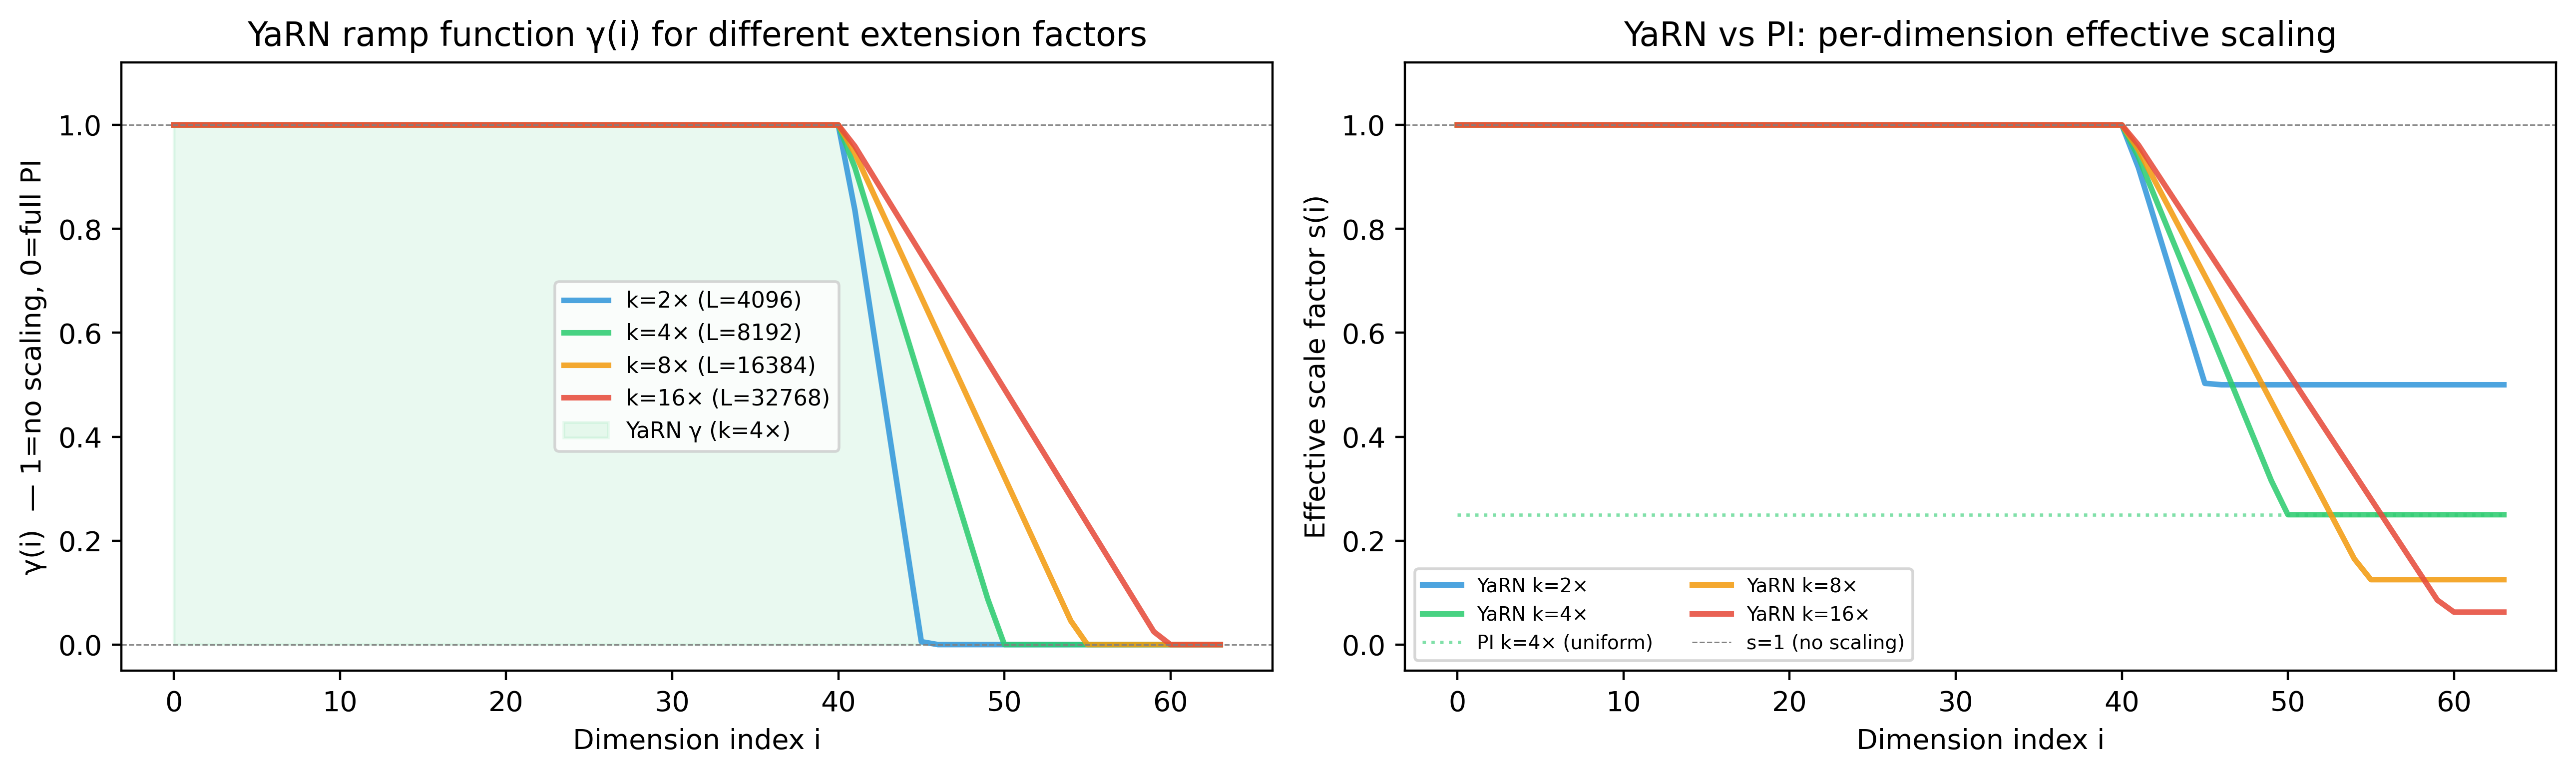

In [43]:
# ============================================================
# Part 2: 三种方法的 per-dimension 插值策略
# ============================================================
def gamma_yarn(lambdas, L0, L):
    """YaRN ramp: 对数空间线性插值权重"""
    g = np.zeros(len(lambdas))
    for j, lam in enumerate(lambdas):
        if lam <= L0:    g[j] = 1.0                                 # 高频：不插值
        elif lam >= L:   g[j] = 0.0                                 # 低频：完全 PI
        else:            g[j] = (np.log(L) - np.log(lam)) / (np.log(L) - np.log(L0))
    return g

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
k_vals = [2, 4, 8, 16]
palette = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

ax = axes[0]
for k, col in zip(k_vals, palette):
    L = k * L0
    g = gamma_yarn(lambdas, L0, L)
    ax.plot(i_vals, g, color=col, lw=2, label=f'k={k}× (L={L})', alpha=0.88)
ax.axhline(1, color='gray', lw=0.5, ls='--')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.fill_between(i_vals, gamma_yarn(lambdas, L0, 4*L0), alpha=0.1, color='#2ecc71', label='YaRN γ (k=4×)')
ax.set_xlabel('Dimension index i')
ax.set_ylabel('γ(i)  — 1=no scaling, 0=full PI')
ax.set_title('YaRN ramp function γ(i) for different extension factors')
ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.12)

ax2 = axes[1]
for k, col in zip(k_vals, palette):
    L = k * L0
    g = gamma_yarn(lambdas, L0, L)
    s_yarn = (L0/L) + g * (1 - L0/L)           # YaRN 有效缩放因子
    s_pi   = np.full_like(i_vals, L0/L, float)  # PI：所有维度均匀缩放
    ax2.plot(i_vals, s_yarn, color=col, lw=2, label=f'YaRN k={k}×', alpha=0.88)
    if k == 4:  # 只展示一个 PI 对比
        ax2.plot(i_vals, s_pi,  color=col, lw=1.2, ls=':', alpha=0.6, label='PI k=4× (uniform)')

ax2.axhline(1.0, color='gray', lw=0.5, ls='--', label='s=1 (no scaling)')
ax2.set_xlabel('Dimension index i')
ax2.set_ylabel('Effective scale factor s(i)')
ax2.set_title('YaRN vs PI: per-dimension effective scaling')
ax2.legend(fontsize=7, ncol=2); ax2.set_ylim(-0.05, 1.12)

plt.tight_layout()
plt.gcf().set_dpi(400)
plt.show()

RoPE 通过复数数乘的方式，让 token 在高维空间中进行旋转，从而编码相对位置信息。

对于输入向量 $x=\left(x_{1}, x_{2}, \ldots, x_{d}\right)$（其中 d 是维度），RoPE 将其拆分为偶数索引和奇数索引
$$\left(x_{1}, x_{2}\right),\left(x_{3}, x_{4}\right), \ldots,\left(x_{d-1}, x_{d}\right)$$

然后，对这些二维向量对进行旋转

$$\left(x^{\prime}, y^{\prime}\right)=(x \cos \theta-y \sin \theta, x \sin \theta+y \cos \theta)$$

中 $\theta$ 由位置 p 和固定基数 10000 计算得到
$$\theta_{i}=\frac{p}{10000^{2 i / d}}$$

适用于 Transformer，通常用于 query 和 key，相乘后会得到相对位置信息。增强注意力机制对相对位置信息的建模。

In [ ]:
import torch

B, T, C = 2, 20, 128
x = torch.randn(B, T, C)
Wq, Wk = torch.nn.Linear(C, C), torch.nn.Linear(C, C)
Q, K = Wq(x), Wk(x)

theta = 10000 ** (-torch.arange(0, C, 2) / C)
theta = theta.expand(size=(20, 64))

pos = torch.arange(0, T).unsqueeze(1)
angles = (pos * theta)
cos = torch.cos(angles)
sin = torch.sin(angles)

q1 = Q[:, :, 0::2]
q2 = Q[:, :, 1::2]
rotated_x1 = q1 * cos - q2 * sin
rotated_x2 = q1 * sin + q2 * cos
Q_rope = torch.stack([rotated_x1, rotated_x2], dim=-1).flatten(-2)

In [47]:
Q_complex = torch.view_as_complex(Q.reshape(B, T, C//2, 2))
freqs = torch.polar(torch.ones(T, C//2), angles)  # e^{iθ}
Q_rope_2 = torch.view_as_real(Q_complex * freqs).flatten(-2)
Q_rope == Q_rope_2

tensor([[[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]],

        [[True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         ...,
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True],
         [True, True, True,  ..., True, True, True]]])